In [1]:
# "모빌로그" 자동차 리콜 데이터 분석 프로젝트

# 자동차 리콜
#### 자동차가 안전 기준에 부적합하거나 안전 운행에 지장을 주는 결함이 있을 때 자동차 제작·조립·수입업체가 결함을 차량 소유자에게 통보하고 수리·교환·환불 등 시정 조치를 하도록 하는 제도. 자동차업체가 자발적으로 시행하는 자기인증적합조사와 정부가 소비자 신고 등으로 인지해 실시하는 제작결함조사 등 두 가지 경로로 이뤄짐.

# 기초 데이터 확인 및 결측지 제거

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import seaborn as sns
import numpy as np


font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕
font = font_manager.FontProperties(fname=font_path)

rc('font', family=font.get_name())
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

In [34]:
df = pd.read_csv(
    "./file/한국교통안전공단_자동차 리콜대수 및 시정률_20221231.csv",
    encoding="cp949"
)
df.head(1)

,제작자,차명,생산기간(부터),생산기간(까지),리콜개시일,리콜대수,리콜사유,시정대수,시정율(퍼센트)
0,자일대우버스 주식회사,BS106(CNG고상버스),2003-01-01,2009-12-31,2014-09-01,3455,자동차의 운행 중 외부의 환경등으로 급격한 타이어 파열시에 타이어 하우징 부식으로 ...,3455,100.0


In [35]:
# 데이터 행,열개수 확인 
df.shape

(9856, 9)

In [36]:
df.columns

Index(['제작자', '차명', '생산기간(부터)', '생산기간(까지)', '리콜개시일', '리콜대수', '리콜사유', '시정대수',
       '시정율(퍼센트)'],
      dtype='object')

In [37]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9856 entries, 0 to 9855
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   제작자       9856 non-null   object 
 1   차명        9856 non-null   object 
 2   생산기간(부터)  9856 non-null   object 
 3   생산기간(까지)  9856 non-null   object 
 4   리콜개시일     9856 non-null   object 
 5   리콜대수      9856 non-null   int64  
 6   리콜사유      9856 non-null   object 
 7   시정대수      9856 non-null   int64  
 8   시정율(퍼센트)  9526 non-null   float64
dtypes: float64(1), int64(2), object(6)
memory usage: 693.1+ KB


제작자           0
차명            0
생산기간(부터)      0
생산기간(까지)      0
리콜개시일         0
리콜대수          0
리콜사유          0
시정대수          0
시정율(퍼센트)    330
dtype: int64

In [38]:
df = df.drop(columns=["시정대수", "시정율(퍼센트)"]) # 필요없는 열 제거
df.head(1)

,제작자,차명,생산기간(부터),생산기간(까지),리콜개시일,리콜대수,리콜사유
0,자일대우버스 주식회사,BS106(CNG고상버스),2003-01-01,2009-12-31,2014-09-01,3455,자동차의 운행 중 외부의 환경등으로 급격한 타이어 파열시에 타이어 하우징 부식으로 ...


In [39]:
# 데이터 기초 통계 확인
df.describe()
# 기술통계 함수라서 수치형 데이터인 컬럼만 보여준다

,리콜대수
count,9856.000000
mean,1878.329444
std,14387.732430
min,1.000000
25%,5.000000
50%,47.000000
75%,363.000000
max,510265.000000


# 칼럼 이름 바꾸기

In [40]:
# 칼럼 이름 바꾸기
df = df.rename(columns={'제작자':'제조사'})
df = df.rename(columns={'생산기간(부터)': '생산시작일'})
df = df.rename(columns={'생산기간(까지)': '생산종료일'})
df.head(1)

,제조사,차명,생산시작일,생산종료일,리콜개시일,리콜대수,리콜사유
0,자일대우버스 주식회사,BS106(CNG고상버스),2003-01-01,2009-12-31,2014-09-01,3455,자동차의 운행 중 외부의 환경등으로 급격한 타이어 파열시에 타이어 하우징 부식으로 ...


# 날짜 변환

In [41]:
# 엑셀 데이터에 2004-01-01 이렇게 나오지만 컴은 글자로 인식해서 '날짜'라는 특수데이터 타입으로 변환해야
# 컴퓨터가 시간의 흐름을 계산 가능
# to_datetime (날짜 변환 함수)
df["생산시작일"] = pd.to_datetime(df["생산시작일"])
df["리콜개시일"] = pd.to_datetime(df["리콜개시일"])

df["생산연도"] = df["생산시작일"].dt.year
df["리콜연도"] = df["리콜개시일"].dt.year
df.head(1)

,제조사,차명,생산시작일,생산종료일,리콜개시일,리콜대수,리콜사유,생산연도,리콜연도
0,자일대우버스 주식회사,BS106(CNG고상버스),2003-01-01,2009-12-31,2014-09-01,3455,자동차의 운행 중 외부의 환경등으로 급격한 타이어 파열시에 타이어 하우징 부식으로 ...,2003,2014


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9856 entries, 0 to 9855
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   제조사     9856 non-null   object        
 1   차명      9856 non-null   object        
 2   생산시작일   9856 non-null   datetime64[ns]
 3   생산종료일   9856 non-null   object        
 4   리콜개시일   9856 non-null   datetime64[ns]
 5   리콜대수    9856 non-null   int64         
 6   리콜사유    9856 non-null   object        
 7   생산연도    9856 non-null   int32         
 8   리콜연도    9856 non-null   int32         
dtypes: datetime64[ns](2), int32(2), int64(1), object(4)
memory usage: 616.1+ KB


# 핵심 관심 칼럼 수량 조사

In [43]:
# 원하는 컬럼 값 출력
df['제조사'].unique()

array(['자일대우버스 주식회사', '(유)기흥모터스', '지엠코리아(주)', '한국지엠(주)', '포드세일즈서비스코리아(유)',
       '포르쉐코리아 주식회사', '현대자동차(주)', '비엠더블유코리아(주)', '(주)재규어랜드로버코리아',
       '만트럭버스코리아(주)', '메르세데스벤츠코리아(주)', '유한회사 모토로싸', '스텔란티스코리아주식회사',
       '(주)볼보자동차코리아', '엠엠에스케이', '혼다코리아(주)', '브이엠케이 주식회사', '한국닛산(주)',
       '쌍용자동차(주)', '폭스바겐그룹코리아 주식회사', '기아주식회사', '대전기계공업(주)', '한국토요타자동차(주)',
       '다임러트럭코리아(주)', '한불모터스(주)', '(주)에프엠케이', '르노코리아자동차 주식회사', '이탈로모토(유)',
       '(주)스즈키씨엠씨', '디앤에이모터스 주식회사', '(주) 오텍', '스바루코리아(주)',
       '(주)캄피오니모토트레이딩', '(주)스포츠모터사이클코리아', '케이알모터스 주식회사', '화창상사(주)',
       '볼보트럭코리아(주)', '기흥인터내셔널 유한회사', '스카니아코리아그룹(주)', '모토스타코리아(주)',
       '타타대우상용차(주)', '주식회사 선롱버스코리아', '진일엔지니어링 주식회사', '(주) 한국모터트레이딩',
       '씨엔에이치인더스트리얼코리아 유한회사', '아이씨피(주)', '(주) 바이크코리아', '(주)오토젠',
       '(주)에이비케이', '씨엑스씨 주식회사', '(주) 다빈월드', '제이에스이엔지', '명성정공', '락락모터스(주)',
       '테슬라코리아 유한회사', '한국쓰리축공업(주)', '명원아이앤씨(주)', '큐로모터스(주)', '(주)테라모터스',
       '허스크바나모터싸이클코리아 주식회사', '(주)에이엠티코리아', '주식회사 마이브', '(주)피라인',
       '폴스타오토모티브코리아 유한회사', '범한자

In [44]:
# 원하는 컬럼 개수
df['제조사'].nunique()

67

In [45]:
df['리콜사유'].nunique()

2197

In [46]:
# 리콜 사유의 빈도수 출력 
df['리콜사유'].value_counts()

리콜사유
배기가스 재순환 장치 냉각기 결함으로 냉각수가 누출될 수 있고, 그 결과 배기가스 재순환 장치 냉각기를 통과하는 배출가스와 만나면, 냉각수 중 수분은 증발하고 글리콜만 남게 됩니다. 글리콜은 WAVE FIN 구조의 내부, 배기가스 재순환 장치 냉각기의 입구 근처, 그리고 배기가스 재순환 장치 냉각기 끝 단에서 배기가스 재순환장치 냉각기 내의 그을음과 혼합될 수 있습니다. 그 곳에서는 혼합물을 발화시키거나 글로잉 입자(열점)를 발생시킬 수 있는 고온 상태가 발생 할 수 있습니다. 이러한 과정에 의하여 글로잉 입자가 흡기다기관 안으로 날아가 흡기다기관 표면에 붙게 되고 해당 영역이 용융하여 천공이 생길 가능성이 있습니다.                                                                                        311
BMW 자체 품질조사 결과 2011년 3월 31일부터 2020년 8월 28일까지 생산된 BMW 118d, 120d, 220d, 320d, 323d, 328d, 420d, 435d, 518d, 520d, 525d, 530d, 535d, 630d, 640d, 730d, 730Ld, 740d, 740Ld,750Ld, 840d, M550d, X1, X3, X4, X4 M40d, X5, X5 M50d, X6, X6 M50d, X7 모델 중 일부 차량에서 극히 드문 경우, 배기가스재순환장치(EGR) 쿨러의 제작결함이 발견 되었습니다.                                                                                                                                              300
당사는 당사의 EGR 쿨러가 이전 리콜 대상 EGR 쿨러에 비하여 개선되고 최적화 되었음을 입증하였습니다. 당사의 철학과 경영 정책에 따라, 개별 현장 사례의 분석을 계속하였습니다. 그 결과, 지속적인 

# 차량나이 계산

In [47]:
df["차량나이"] = df["리콜연도"] - df["생산연도"] #데이터 프레임에서 차량나이 칼럼 추가 => 차량 나이 = 리콜연도 - 생산 연도
df.head(3)

,제조사,차명,생산시작일,생산종료일,리콜개시일,리콜대수,리콜사유,생산연도,리콜연도,차량나이
0,자일대우버스 주식회사,BS106(CNG고상버스),2003-01-01,2009-12-31,2014-09-01,3455,자동차의 운행 중 외부의 환경등으로 급격한 타이어 파열시에 타이어 하우징 부식으로 ...,2003,2014,11
1,자일대우버스 주식회사,BS090,2003-01-01,2009-12-31,2014-09-01,1811,자동차의 운행 중 외부의 환경등으로 급격한 타이어 파열시에 타이어 하우징 부식으로 ...,2003,2014,11
2,(유)기흥모터스,DYNA LOW RIDER,2014-01-06,2014-06-19,2014-09-01,8,이그니션 스위치 브라켓의 문제로 인하여 엔진 고회전주행시 스위치가 움직여 시동이 꺼...,2014,2014,0


In [48]:
df['차량나이'].describe()

count    9856.000000
mean        4.314022
std         4.147571
min         0.000000
25%         1.000000
50%         3.000000
75%         6.000000
max       115.000000
Name: 차량나이, dtype: float64

In [49]:
# 차량나이(timedelta)를 '년' 단위의 정수형 숫자로 변환
# - df["차량나이"] 는 timedelta64[ns] 타입 (예: 4261 days)
# - .dt.days : 일(day) 단위의 정수로 변환
# - // 365 : 365일 기준으로 나눈 뒤 소수점 버림 → '차량나이(년)'
#df1["차량나이_년"] = df1["차량나이"].dt.days // 365


# 차량 나이 115년 짜리는 현실적으로 불가능하여 배제히고 30년 이하까지만 진행
# count = 9,856,리콜 사건이 총 9,856건 있다
# 리콜은 평균적으로 출고 후 약 4.3년쯤에 발생
# 리콜 발생 시점이 꽤 넓게 퍼져 있다, 
# 어떤 차는 1년 만에 어떤 차는 10년 넘어서-> 리콜 원인이 하나가 아니라는 뜻 초기 설계 문제,중기 내구 문제,노후화 문제
# 출고된 해에 바로 리콜된 사례가 있음

# ; 차량 나이별 리콜 빈도수를 그래프로 보여주면 더 잘 증명할 수 있을 듯


# 전체 리콜 중 25%는 출고 후 1년 이내
# 절반의 리콜은 출고 후 3년 이내에 발생
# 리콜의 75%는 출고 후 6년 이내
# 출고 후 115년 후 리콜? -> 불가능 # 
# 데이터 이상치(Outlier) 문제: 차량 나이 계산 결과, 최소 0세부터 최대 115세까지 계산되는 데이터가 발견되었습니다. 
# (예: 다임러트럭 생산연도가 1900년으로 기입된 사례) 
# 이러한 이상치는 평균치를 왜곡하므로 분석 전 반드시 제거하거나 보정해야 함
df = df[
    (df["차량나이"] >= 0) &
    (df["차량나이"] <= 30)
    ].copy()

df['차량나이'].describe()

count    9855.000000
mean        4.302790
std         3.995081
min         0.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        24.000000
Name: 차량나이, dtype: float64

In [50]:
# 결측치 없는 거 확인
df['차량나이'].isna().sum()

np.int64(0)

# 차량나이 구간 나누기

In [51]:
# “차량나이(시간 데이터)를 숫자로 바꾸고 → 구간화해서 분석용 범주로 만드는” 데이터 전처리 핵심 루틴
bins = [-1, 2, 4, 6, 10, 100] # 차량 나이를 나눌 기준점(경계값)을 정한다
labels = ["0-2년", "3-4년", "5-6년", "7-10년", "10년 이상"] # 구간 이름
df["차량나이구간"] = pd.cut(
    df["차량나이"],
    bins=bins,
    #차량나이를 구간화하기 위한 기준값 설정
    # 연속형 숫자 데이터를 범주형 데이터로 변환하기 위한 구간 경계
    labels=labels,# 각 차량나이 구간에 부여할 라벨(사람이 읽기 쉬운 형태)
    include_lowest=True, # include_lowest=True : 최솟값(0년) 포함
    right=True # right=True : 오른쪽 경계값 포함 (예: 2 → 0-2년)
)
df.head(10)

,제조사,차명,생산시작일,생산종료일,리콜개시일,리콜대수,리콜사유,생산연도,리콜연도,차량나이,차량나이구간
0,자일대우버스 주식회사,BS106(CNG고상버스),2003-01-01,2009-12-31,2014-09-01,3455,자동차의 운행 중 외부의 환경등으로 급격한 타이어 파열시에 타이어 하우징 부식으로 ...,2003,2014,11,10년 이상
1,자일대우버스 주식회사,BS090,2003-01-01,2009-12-31,2014-09-01,1811,자동차의 운행 중 외부의 환경등으로 급격한 타이어 파열시에 타이어 하우징 부식으로 ...,2003,2014,11,10년 이상
2,(유)기흥모터스,DYNA LOW RIDER,2014-01-06,2014-06-19,2014-09-01,8,이그니션 스위치 브라켓의 문제로 인하여 엔진 고회전주행시 스위치가 움직여 시동이 꺼...,2014,2014,0,0-2년
3,지엠코리아(주),캐딜락CTS,2010-12-22,2012-12-06,2014-09-01,329,"차량 키에 액세서리나 무거운 물체를 매달어 사용하는 경우, 오프로드 주행시, 차가 ...",2010,2014,4,3-4년
4,한국지엠(주),올란도 2.0 LPG,2011-11-07,2012-01-16,2012-04-27,1323,좌석이 정확히 고정되지 않아 주행 중 고정 장치가 빠질 경우 안전운행에 지장을 줄 ...,2011,2012,1,0-2년
5,한국지엠(주),올란도 2.0 디젤,2011-11-07,2012-01-16,2012-04-27,571,좌석이 정확히 고정되지 않아 주행 중 고정 장치가 빠질 경우 안전운행에 지장을 줄 ...,2011,2012,1,0-2년
6,포드세일즈서비스코리아(유),포커스,2011-06-13,2011-10-18,2012-04-30,295,와이퍼 모터 커넥터에 수분이 유입되어 작동이 되지 않아 운전자의 시야확보가 어려워 ...,2011,2012,1,0-2년
7,포르쉐코리아 주식회사,박스터 S,2012-01-09,2012-04-18,2012-05-02,3,연료라인 연결장치 결함으로 주행 중 누유되어 안전운행에 지장,2012,2012,0,0-2년
8,현대자동차(주),베라크루즈,2007-05-07,2013-06-28,2014-09-30,1754,엔진 헤드커버 가스켓 형상 부적합으로 장기간 사용 시 오일 미세 누유로 인해 간헐적...,2007,2014,7,7-10년
9,비엠더블유코리아(주),C600S,2012-03-23,2013-12-05,2014-08-20,290,체인텐셔너 내부의 스프링을 고정하는 장치가 경우에 따라 비정상저인 마모가 진행될 수...,2012,2014,2,0-2년


In [52]:
# 차량 나이 구간 결측치 없는거 확인
df['차량나이구간'].isna().sum()

np.int64(0)

In [53]:
# 차량 리콜 구간이 어떤 차량나이에 가장 몰려있는지 오름차순으로 확인
df['차량나이구간'].value_counts().sort_index()

차량나이구간
0-2년      4287
3-4년      1847
5-6년      1422
7-10년     1553
10년 이상     746
Name: count, dtype: int64

# 리콜 사유를 분류하는 핵심 키워드

In [54]:
PART_KEYWORDS = {
        "엔진": ["엔진", "실린더", "피스톤", "타이밍", "EGR 밸브", "커넥팅로드", "동력", "냉각", "라디에이터"],

    "배터리": ["배터리", "충전", "BMS", "고전압", "절연", "셀"],

    "소프트웨어": ["제어", "소프트웨어", "프로그램", "로직", "ECU", "MCU", "통신", "센서", "경고등", "업데이트", "시스템"],

    "주행/제동/조향": ["브레이크", "제동", "ABS", "ESC", "조향", "스티어링", "핸들", "기어보드"],

    "안전": ["에어백", "SRS", "안전벨트", "프리텐셔너", "좌석", "시트", "유아용", "고정"],

    "등화": ["램프", "등", "헤드램프", "방향지시등", "후미등", "유리", "와이퍼", "미러"],

    "연료/배기": ["연료", "펌프", "인젝터", "누유", "배출", "촉매", "DPF"],

    "외장": ["차체", "프레임", "부식", "라벨", "표기", "기준", "캡", "도어", "래치"]
}


In [55]:
def classify_recall(reason): #리콜 사유 함수 정의
    reason = str(reason) 
    # 리콜 사유가 NaN이거나 다른 타입이어도 문자열로 변환하여
    # in 연산(word in reason)이 가능하도록 처리

    for category, keywords in PART_KEYWORDS.items(): #딕셔너의 언패킹
        # category와 keywords에 저장 -> categoty는 엔진, 배터리..., keywords는 그에 속하는 리스트 
        for word in keywords: # keywords 리스트(예 : 실린더)를 word에 저장
            if word in reason:
                # 리콜 사유 문자열(reason)에
                # 특정 키워드(word)가 포함되어 있는지 확인
                return category # 카테고리로 반환
    return "기타" # 그렇지 않으면 기타로 분류

df["카테고리"] = df['리콜사유'].apply(classify_recall) # 리콜 사유를 함수에 적용
print(df['카테고리'].value_counts()) # 카테고리 값들의 개수를 센다

카테고리
엔진          2621
소프트웨어       1745
안전          1729
기타          1507
주행/제동/조향     717
연료/배기        548
등화           532
외장           270
배터리          186
Name: count, dtype: int64


In [56]:
# 1. '세부키워드'를 찾아내는 로직 (기존 딕셔너리 활용)
def get_keyword(text): # text = 리콜 사유 한 줄 전체
    for cat, keywords in PART_KEYWORDS.items(): #딕셔너리의 언패킹
    # KEYWORDS에서 키:값 쌍으로 계속 뽑아서 cat, keywords에 저장
        for k in keywords: # keywords를 하나씩 뽑아 k에 저장
            if k in text: # text(리콜사유 문장) 안에 k(키워드)가 포함되어 있는지 검사
                return k # k 반환
    return "기타"

# 2. 전체 데이터프레임에 적용 (단 한 번만 수행)
df['세부키워드'] = df['리콜사유'].apply(get_keyword)

# 3. 트리맵을 위한 요약 테이블 만들기 (8개 카테고리 전체가 포함됨)
# 카테고리별, 세부키워드별로 '건수'를 자동으로 계산

df_summary = df.groupby(['카테고리', '세부키워드']).size().reset_index(name='리콜건수')
# 카테고리를 기준으로 먼저 그룹화하고,그 안에서 세부키워드 기준으로 다시 그룹화
# df.groupby(['카테고리', '세부키워드']).size() : 멀티 인덱스
# .reset_index(name='리콜건수') : 멀티 인덱스를 표로 만듬

# 4. 트리맵 그리기 (이 코드 한 번이면 8개 카테고리가 한 화면에 나옵니다)
import plotly.express as px
# Plotly의 고수준 시각화 API
# 복잡한 설정 없이도 계층 시각화 가능

fig = px.treemap(df_summary, 
                 path=['카테고리', '세부키워드'], # 계층: 카테고리 밑에 세부키워드 배치
                 values='리콜건수',             # 사각형 크기는 '리콜건수'로 결정
                 color='카테고리',               # 색상은 카테고리별로 다르게
                 title='카테고리별 세부 리콜 사유',
                 height = 800)

fig.show()

# 차량나이별 리콜 대수

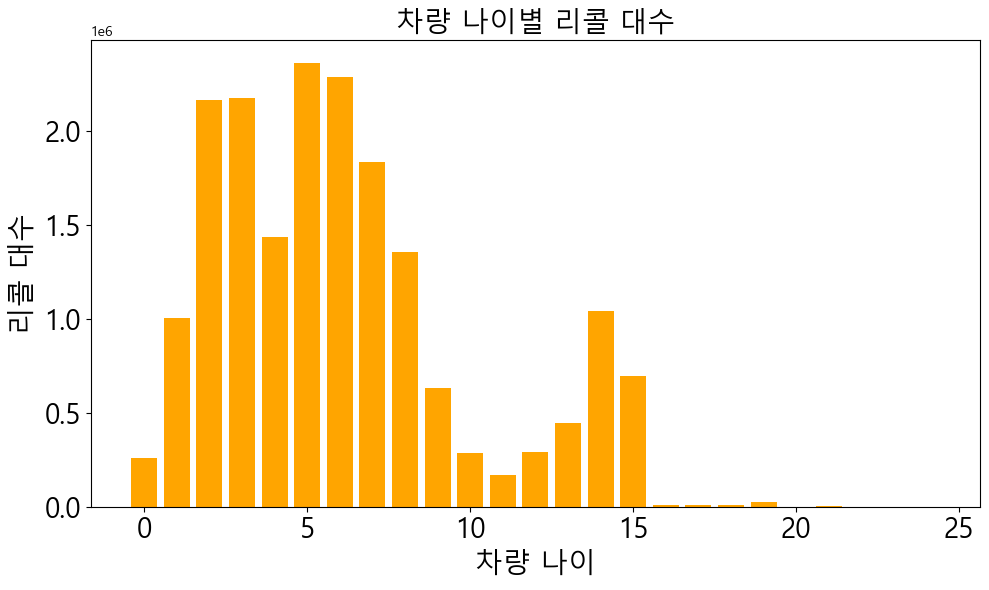

In [57]:
## 1. 차량나이별로 리콜대상대수의 합계를 구함
age_volume = df.groupby('차량나이')['리콜대수'].sum()

# 2. 막대그래프 그리기
plt.figure(figsize=(10, 6))
plt.bar(age_volume.index, age_volume.values, color='orange')
plt.title('차량 나이별 리콜 대수', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.xlabel('차량 나이',fontsize = 20)
plt.ylabel('리콜 대수', fontsize = 20)
plt.savefig('1.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# 차량나이별 리콜사유

C:\Users\KDS26\AppData\Local\Temp\ipykernel_26084\341842390.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\KDS26\AppData\Local\Temp\ipykernel_26084\341842390.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



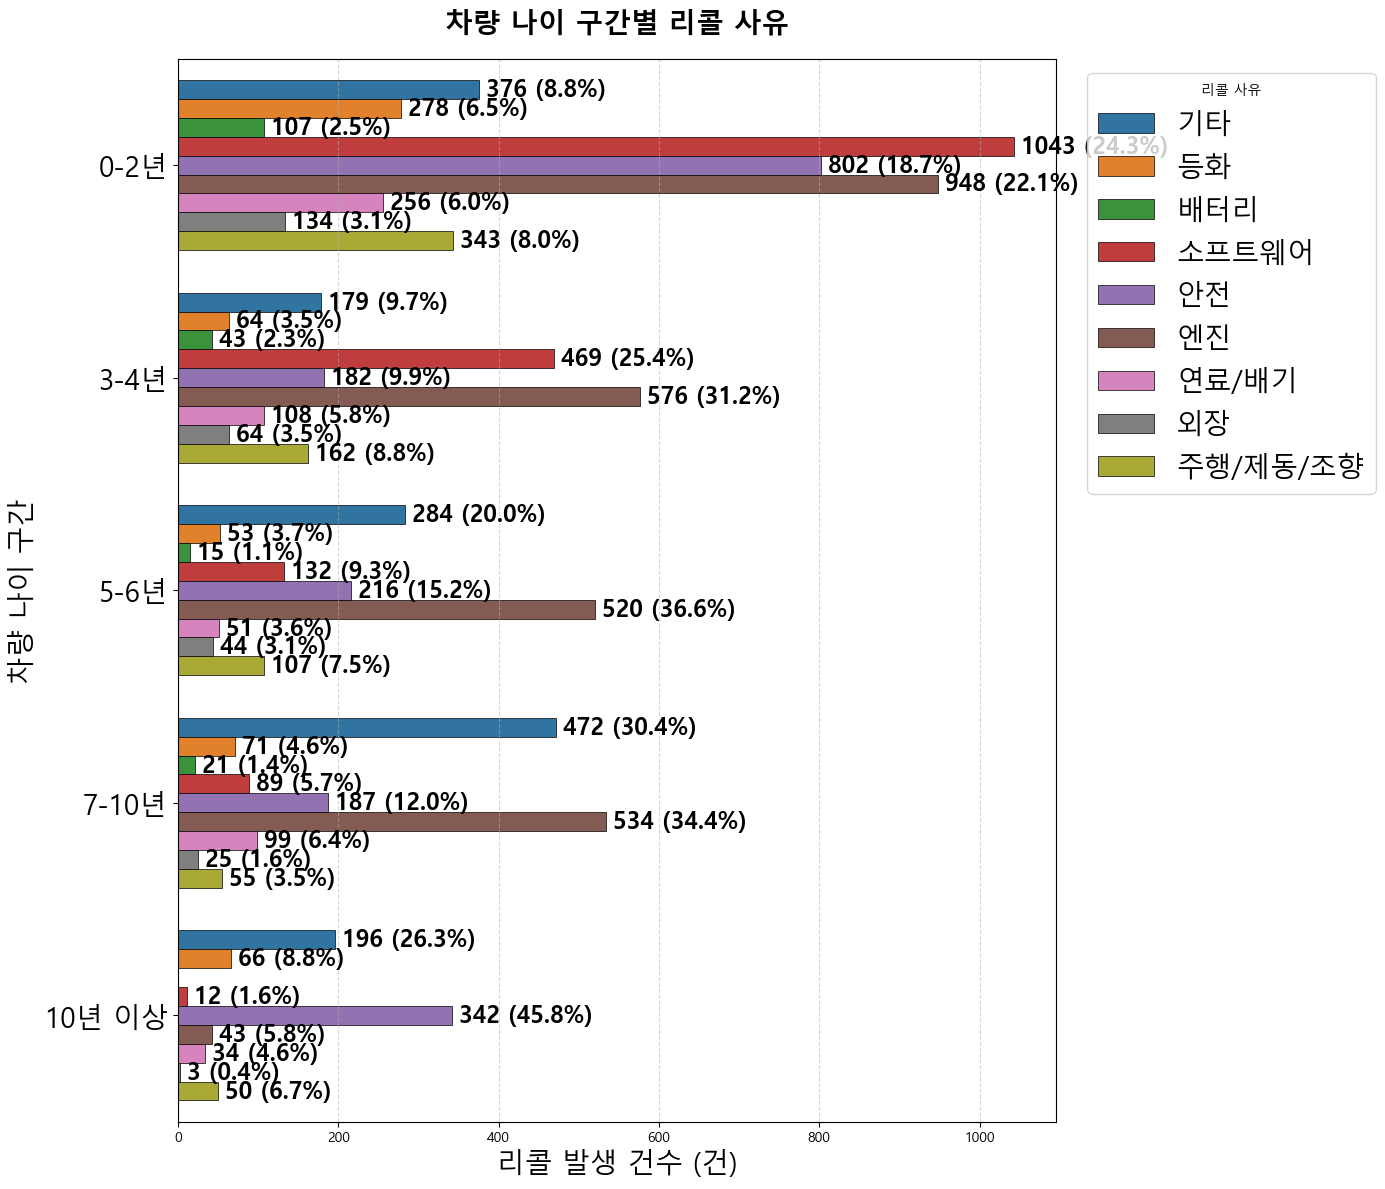

In [58]:
# 1. 데이터 집계 및 비중 계산
# 구간별/카테고리별 건수 계산
df_counts = df.groupby(['차량나이구간', '카테고리']).size().reset_index(name='count')

# 각 '차량나이구간' 내에서의 비중(%) 계산
df_counts['percentage'] = df_counts.groupby('차량나이구간')['count'].transform(lambda x: (x / x.sum()) * 100)

# 2. 정렬 순서 정의
order_list = ["0-2년", "3-4년", "5-6년", "7-10년", "10년 이상"]
df_counts['차량나이구간'] = pd.Categorical(df_counts['차량나이구간'], categories=order_list, ordered=True)

# !!! 중요: Seaborn의 막대 생성 순서(Hue 그룹별 -> 구간별)와 일치시키기 위해 데이터를 정렬
df_counts = df_counts.sort_values(['카테고리', '차량나이구간'])

# 3. 그래프 그리기
plt.figure(figsize=(14, 12))
ax = sns.barplot(data=df_counts, 
                 y='차량나이구간', 
                 x='count', 
                 hue='카테고리', 
                 order=order_list,
                 palette='tab10',
                 edgecolor='black',
                 linewidth=0.5)

# 4. 레이블 추가 (건수와 %를 동시에 표시)
# 정렬된 데이터프레임의 퍼센트 값을 순서대로 가져와서 막대에 매칭
percentages = df_counts['percentage'].values

for i, p in enumerate(ax.patches):
    width = p.get_width()
    if width > 0:
        # i번째 막대에 해당하는 퍼센트 값을 가져옴
        pct = percentages[i]
        
        # 텍스트 형식: "건수 (비중%)"
        label = f'{int(width)} ({pct:.1f}%)'
        
        ax.annotate(label, 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=17, fontweight='bold')

# 5. 그래프 세부 설정
# y축 눈금 라벨의 폰트 크기를 20으로 설정
plt.yticks(fontsize=20)
plt.title('차량 나이 구간별 리콜 사유', fontsize=20, pad=20, fontweight='bold')
plt.xlabel('리콜 발생 건수 (건)', fontsize=20)
plt.ylabel('차량 나이 구간', fontsize=20)
plt.legend(title='리콜 사유', bbox_to_anchor=(1.02, 1), loc='upper left',fontsize = 20)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.savefig('2.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

plt.show()


C:\Users\KDS26\AppData\Local\Temp\ipykernel_26084\2123066833.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



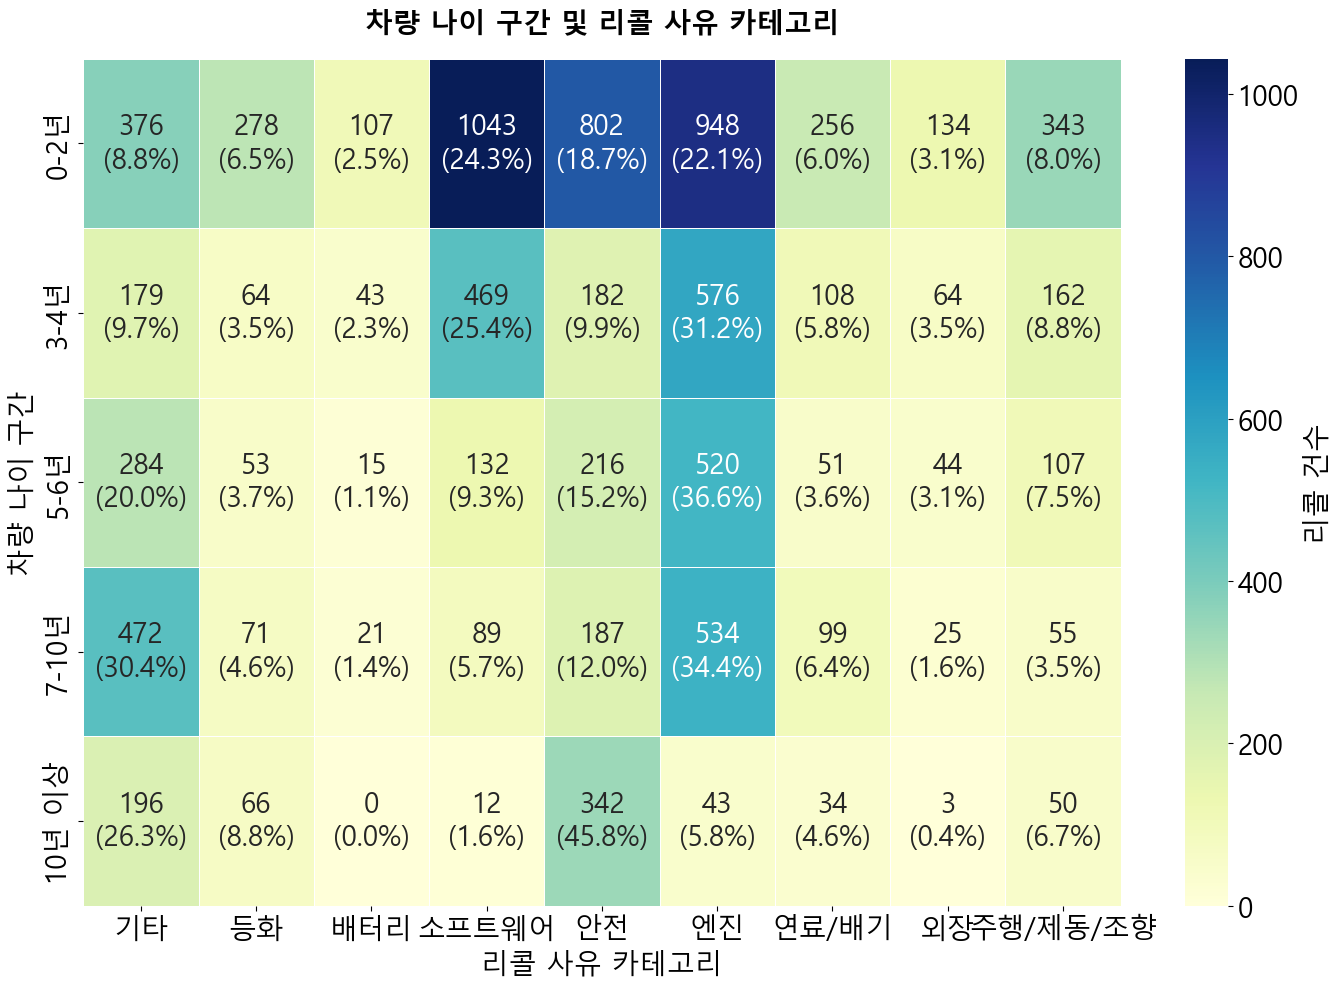

In [59]:
# 1. 히트맵을 위한 데이터 재구성
heatmap_data = df.groupby(['차량나이구간', '카테고리']).size().unstack(fill_value=0)
# 차량 나이와 리콜사유를 묶어 그룹을 만들고, 각 그룹에 데이터가 몇 개 있는 지 계산, 세로로 길게 늘어진 데이터를 피봇테이블 형태로 펼쳐줌
# 차량나이구간은 행으로 카테고리는 열로 보냄.데이터가 없는 칸 NaN은 0으로 채움

# 2. 행 순서 고정
order = ["0-2년", "3-4년", "5-6년", "7-10년", "10년 이상"]
# 존재하는 인덱스만 필터링하여 에러 방지
heatmap_data = heatmap_data.reindex([o for o in order if o in heatmap_data.index])
# 리스트 컴프리핸션; order 리스트를 하나씩 돌면서, 그 항목이 실제 데이터의 인덱스에 있는지 확인
# 있는 것만 모아서 새로운 순서 리스트 만들어 행 다시 재정

# 3. 비율 계산 및 텍스트 행렬(annot_data) 생성
row_sums = heatmap_data.sum(axis=1)
percent_data = heatmap_data.div(row_sums, axis=0) * 100

# 표시할 문자열 생성: "건수\n(비율%)"
annot_data = np.array([[f"{int(count)}\n({pct:.1f}%)" 
                        for count, pct in zip(row_cnt, row_pct)] 
                       for row_cnt, row_pct in zip(heatmap_data.values, percent_data.values)])
# 개수 데이터와 퍼센트 데이터의 행을 동시에 하나씩 꺼내오면
# 첫번째 행의개수(row_cnt)와 첫번째 행의 퍼센트들(row_pct)가 한쌍이 되어 나옴
# 가져온 값들을 문자열로 만드는데 int(count); 개수는 정수형으로 바꾸고 
# \n은 줄바꿈,(위에는 개수, 아래에는 퍼센트가 표시되게 함)
#  {pct:.1f}%)는 퍼센트는 소수점 첫째자리까지 표시, 뒤에 % 붙임
#  이 문자열을 2차원 리스트로 모은 뒤에 numpy array 로 변

# 4. 히트맵 그리기
plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, 
            annot=annot_data,    # 생성한 텍스트 행렬 적용
            fmt="",              # 문자열 포맷팅 유지
            cmap='YlGnBu',          # 색상 조합 (노랑-초록-파랑)
            linewidths=0.5,             # 칸 사이 경계선
            cbar_kws={'label': '리콜 건수'}, #오른쪽에 생기는 색상 막대(범례)의 이름을 설정
            annot_kws={"size": 20})      # 텍스트 크기 조절
cbar = plt.gca().collections[0].colorbar
cbar.set_label('리콜 건수', fontsize=20)
cbar.ax.tick_params(labelsize=20)

# y축 눈금 라벨의 폰트 크기를 20으로 설정
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('차량 나이 구간 및 리콜 사유 카테고리', fontsize=20, pad=20, fontweight='bold')
plt.xlabel('리콜 사유 카테고리', fontsize=20)
plt.ylabel('차량 나이 구간', fontsize=20)

plt.savefig('recall_heatmap.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# 차량 나이 구간별 리콜 TOP5 제조사

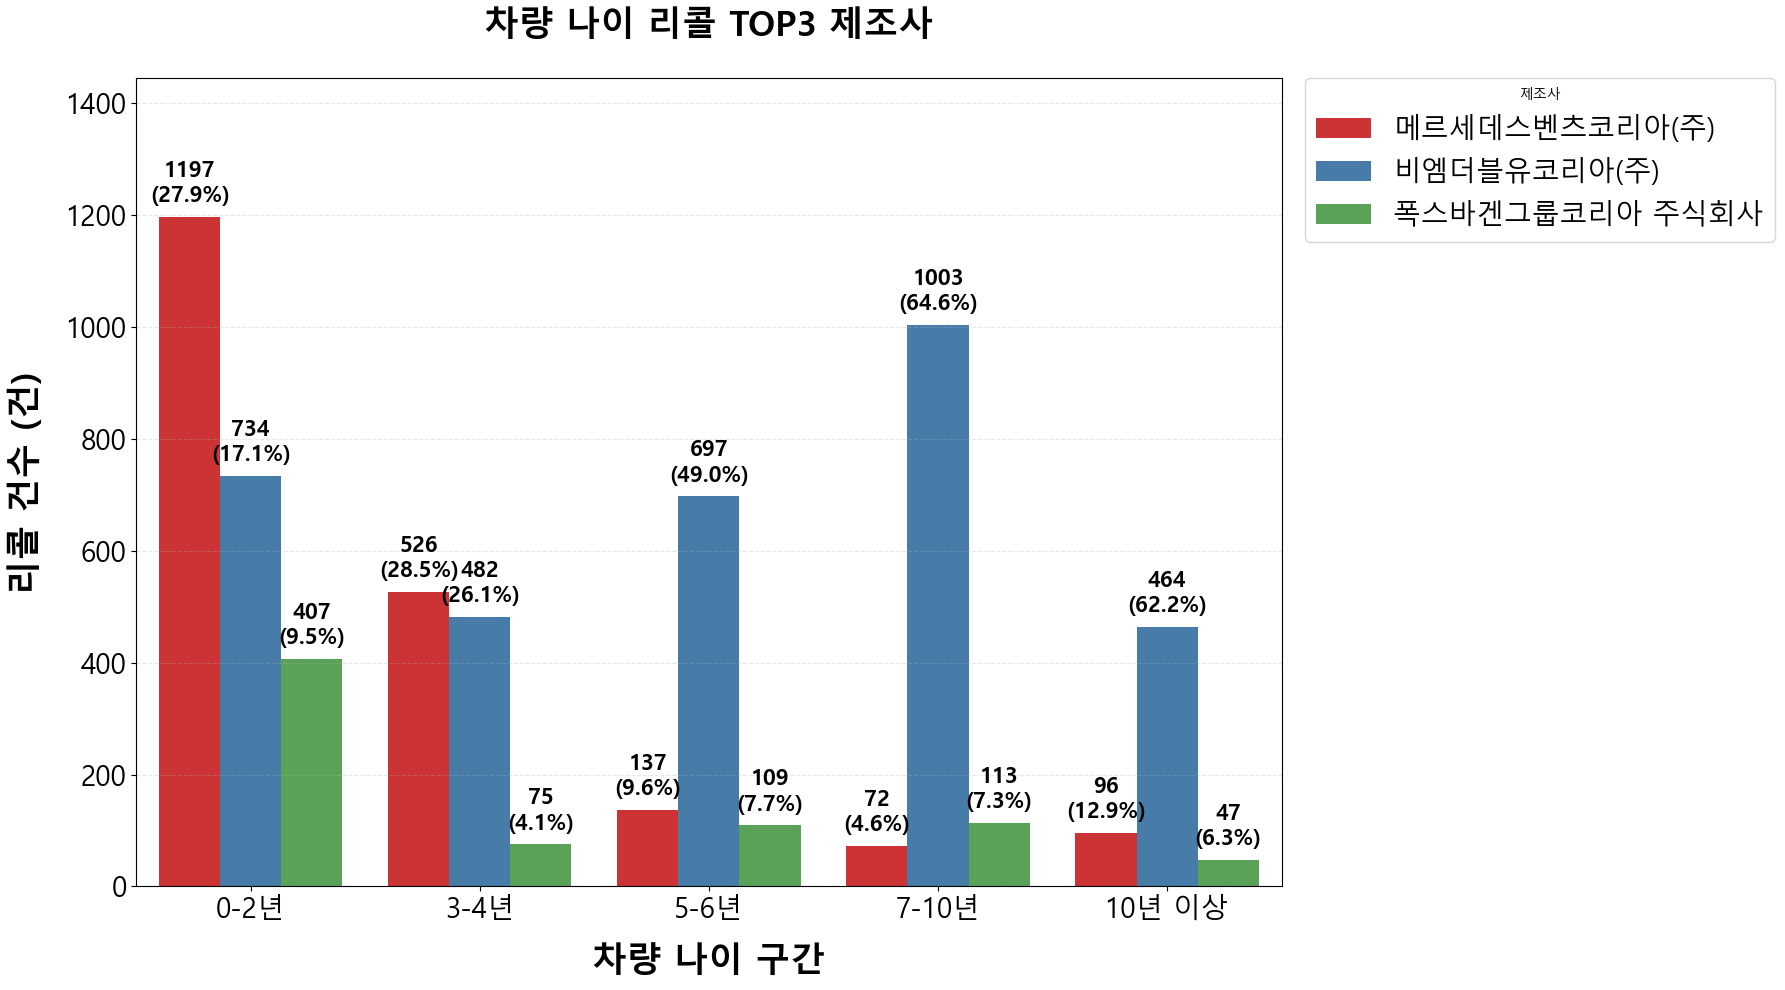

In [60]:
# 1. 데이터 집계 및 Top 5 추출
# 각 차량나이구간과 제조사별로 그룹화해서 데이터개수(리콜건수) 세고 프레임 초기화
df_counts = df.groupby(['차량나이구간', '제조사'], observed=True).size().reset_index(name='리콜건수')
# observed=True; 카테고리형 데이터 중 실제 데이터가 존재하는 조합만 계산->경고방
# 각 차량나이별로 전체 리콜건수 합을 구해 딕셔너리형태로 저장(점유율계산)
group_totals = df_counts.groupby('차량나이구간', observed=True)['리콜건수'].sum().to_dict()

#각 구간별 리콜건수 가장 많은 상위 5개 제조사만 추
# include_groups=False를 설정하여 apply 내부에서 그룹화 기준이 된 컬럼을 중복 포함하지 않게 관련 경고 해결
df_top5 = df_counts.groupby('차량나이구간', observed=True).apply(
    lambda x: x.nlargest(3, '리콜건수'), include_groups=False
).reset_index()

# 2. 그래프 그리기
plt.figure(figsize=(18, 10)) # 그래프 전체크기 가로18인, 세로10인치
# x축에 표시될 구간의 순서를 명확하게 정
order_list = ["0-2년", "3-4년", "5-6년", "7-10년", "10년 이상"]

# seaborn의 barplot 이용해서 막대그래프 생성
ax = sns.barplot(data=df_top5, 
                 x='차량나이구간', 
                 y='리콜건수', 
                 hue='제조사',   # 제조사별로 색상 다르게 표시
                 order=order_list, # 정의한 순서대로 x축 정렬
                 palette='Set1',   # 선명한 팔레트 색상 선택
                 # edgecolor='black', # 막대 테두리 검정색
                 linewidth=1)       # 테두리 두께 1

# 3. 막대 위에 데이터 레이블 추가
# 그래프에 그려진모든 막대요소(patches)를 하나씩 순 
for p in ax.patches:
    height = p.get_height() # 막대 높이(리콜건수) 가져
    if height > 0:          # 건수가 0보다 큰 경우에만 레이블 표시 
        x_center = p.get_x() + p.get_width() / 2.    # 막대릐 가로 중앙 위치 계산
        # x_center 값에 따라 적절한 그룹 인덱스 매칭
        group_idx = int(round(x_center)) # x_center(좌표값)를 반올림하여 현재 막대가 속한 X축의 그룹 인덱스(0~4) 찾
        
        # 인덱스가 유효한 범위 내에 있는지 확인
        if 0 <= group_idx < len(order_list):
            current_group = order_list[group_idx] # 현재 막대의 구간 이름(예: '0-2년')
            total_in_group = group_totals.get(current_group, 1) # 해당 구간의 전체 건수를 가져
            percentage = (height / total_in_group) * 100 # 전체 대비 현재 제조사의 점유율을 계산

            # 표시할 텍스트 형식: 건수(정수)와 점유율(소수점 1자리)
            label_text = f'{int(height)}\n({percentage:.1f}%)'
            # 계산된 위치에 텍스트를 기입
            ax.annotate(label_text, 
                        (x_center, height),  # 텍스트가 위치할 좌표 (중앙, 상단)
                        ha = 'center', va = 'bottom', # 정렬 설정 (가로 중앙, 세로 하단 기준)
                        xytext = (0, 7), # 좌표로부터 위로 7포인트만큼 띄움
                        textcoords = 'offset points',
                        fontsize=16, 
                        fontweight='bold',
                        linespacing=1.2) # 줄 간격 설정

# 4. 세부 디자인 조정
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('차량 나이 리콜 TOP3 제조사', fontsize=25, pad=30, fontweight='bold')
plt.xlabel('차량 나이 구간', fontsize=25, fontweight='bold', labelpad=15)
plt.ylabel('리콜 건수 (건)', fontsize=25, fontweight='bold', labelpad=15)

# 범례를 그래프 우측 바깥에 배
plt.legend(title='제조사', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.,fontsize = 20)
plt.grid(axis='y', linestyle='--', alpha=0.3) # Y축(숫자 어디에 해당되는지)에만 점선 그리드 표시

# 레이블이 그래프 상단 끝에 걸리지 않도록 Y축 최대 범위를 15% 정도 늘
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.savefig('recall_top3_analysis.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [61]:
# 1. 각 구간별 TOP 5 제조사 리스트 추출
#  df_top5 데이터프레임을 활용
target_manufacturers = df_top5['제조사'].unique()

# 전체 데이터에서 해당 제조사들만 필터링
df_filtered = df[df['제조사'].isin(target_manufacturers)].copy()

# 나이 구간 순서 고정
age_order = ["0-2년", "3-4년", "5-6년", "7-10년", "10년 이상"]
df_filtered['차량나이구간'] = pd.Categorical(df_filtered['차량나이구간'], categories=age_order, ordered=True)

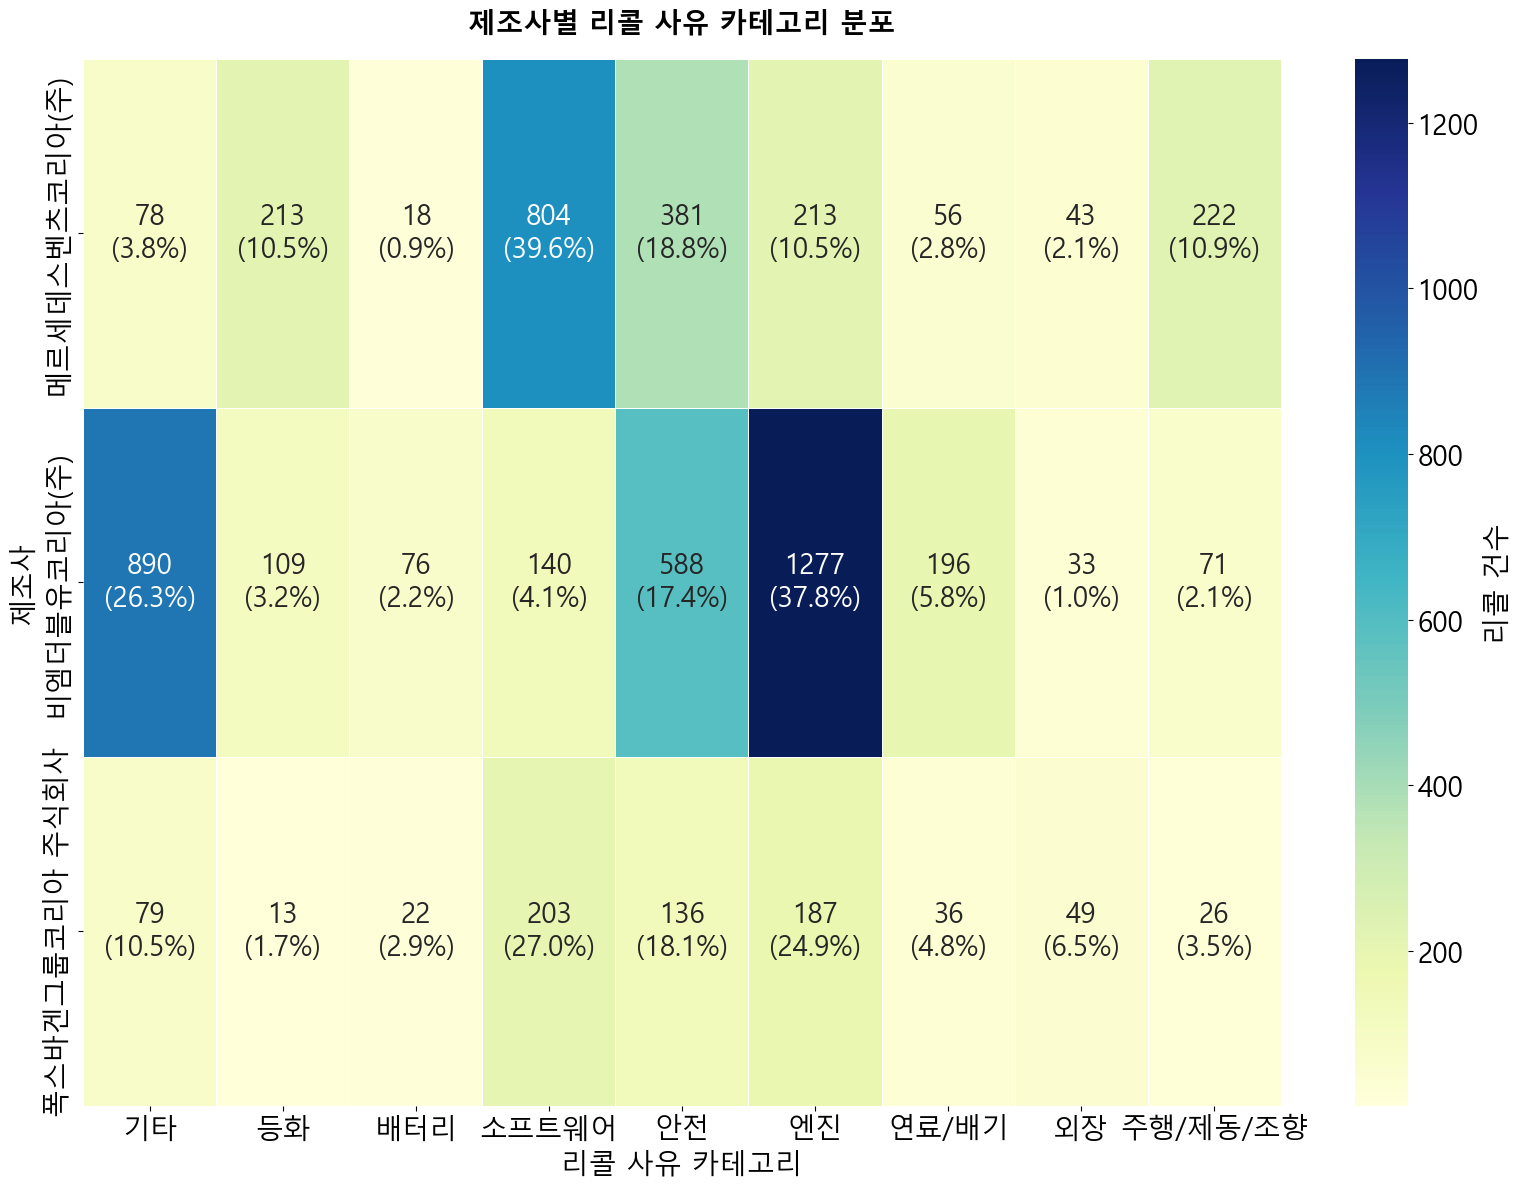

In [64]:
# 1. 데이터 재구성: 제조사 x 카테고리
hm1_data = df_filtered.groupby(['제조사', '카테고리']).size().unstack(fill_value=0)

# --- 비율 계산 및 텍스트 행렬 생성 (추가된 부분) ---
# 각 행(제조사)별 리콜 총합 계산
row_sums = hm1_data.sum(axis=1)

# 각 셀의 건수를 행 총합으로 나눠 점유율(%) 계산
hm1_pct = hm1_data.div(row_sums, axis=0) * 100

# 표시할 텍스트 행렬 생성: "건수\n(비율%)"
# hm1_data와 hm1_pct의 값을 순회하며 문자열 리스트를 만듦
annot_matrix = np.array([[f"{int(val)}\n({pct:.1f}%)" 
                          # 문자열을 만드는데 개수데이터는 소수점이 없도록 정수로 바꿈
                            # \n; 줄바꿈 문자로 숫자가 위, 백분율이 아래에 놓이게
                            #  {pct:.1f}; 백분율 데이터를 소수점 첫째자리까지 표현 뒤에 % 기호 붙임
                          for val, pct in zip(row_val, row_pct)] 
                         #  가져온 두 행 안에서 같은 위치에 있는 칸들을 다시 짝지어 개수하나, 백분율 하나 꺼내옴
                         for row_val, row_pct in zip(hm1_data.values, hm1_pct.values)]) 
                         # 데이터프레임에서 순수하게 숫자데이터만 꺼내서 같은 위치에 있는 행들을 짝을 지어
                         # 한번의 루프마다 개수데이터 1줄과 백분율 데이터 1줄을 각각 가져옴

plt.figure(figsize=(16, 12)) # 텍스트 표시를 위해 크기를 조금 더 키움

sns.heatmap(hm1_data, 
            annot=annot_matrix,   # 위에서 만든 텍스트 행렬을 직접 전달
            fmt="",               # 이미 문자열로 포맷팅했으므로 빈 문자열 설정
            cmap='YlGnBu', 
            linewidths=0.5, 
            cbar_kws={'label': '리콜 건수'},
            annot_kws={"size":20}) # 텍스트 크기 조절

cbar = plt.gca().collections[0].colorbar
cbar.set_label('리콜 건수', fontsize=20)
cbar.ax.tick_params(labelsize=20)

            
plt.title('제조사별 리콜 사유 카테고리 분포', fontsize=20, pad=20, fontweight='bold')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('리콜 사유 카테고리', fontsize=20)
plt.ylabel('제조사', fontsize=20)

plt.savefig('hitmap_recall_top5_analysis.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [63]:
# 분석 결과 

차량나이 0~ 2년에는 
소프트웨어-엔진-안전 사유 순으로 리콜이 제일 많이 발생한다.
벤츠 - BMW 순 리콜건수 다수 발생

차량나이 3~4년에는 
엔진-소프트웨어 사유로 인한 리콜이 대부분이다.
벤츠 - BMW 순

차량나이 5~6년에는 
엔진-기타 사유 순을 리콜이 많이 발생한다.
여기서부터 BMW가 벤츠를 앞서가면서 리콜 많이 발생 압도적인 차이! 

차량나이 7~10년에는 
엔진- 기타 사유 순으로 리콜이 많이 발생한다.
BMW가 가장 많이 발생

차량나이 10년 이후에는 
안전-엔진 사유로 리콜이 많이 발생한다. 
BMW가 가장 많이 발생 